In [7]:
# Import libraries (using existing ones)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("📊 Ready to start flood prediction modeling!")

✅ Libraries imported successfully!
📊 Ready to start flood prediction modeling!


In [8]:
# Load the datasets
print("📊 Loading datasets...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"✅ Training data shape: {train_df.shape}")
print(f"✅ Test data shape: {test_df.shape}")
print(f"✅ Training columns: {train_df.columns.tolist()}")

# Display basic info
print("\n�� Training Data Info:")
print(train_df.info())

print("\n�� Test Data Info:")
print(test_df.info())

📊 Loading datasets...
✅ Training data shape: (1117957, 22)
✅ Test data shape: (745305, 21)
✅ Training columns: ['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']

�� Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverM

In [9]:
# Display first few rows
print("🔍 Training Data Preview:")
display(train_df.head())

print("\n🔍 Test Data Preview:")
display(test_df.head())

🔍 Training Data Preview:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415



🔍 Test Data Preview:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,1117957,4,6,3,5,6,7,8,7,8,...,8,5,7,5,6,3,6,4,4,5
1,1117958,4,4,2,9,5,5,4,7,5,...,2,4,7,4,5,1,7,4,4,3
2,1117959,1,3,6,5,7,2,4,6,4,...,7,9,2,5,5,2,3,6,8,3
3,1117960,2,4,4,6,4,5,4,3,4,...,7,8,4,6,7,6,4,2,4,4
4,1117961,6,3,2,4,6,4,5,5,3,...,4,3,2,6,4,6,8,4,5,5


In [10]:
# Check for missing values
print("🔍 Missing Values Analysis:")
print("\nTraining Data Missing Values:")
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "No missing values found!")

print("\nTest Data Missing Values:")
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "No missing values found!")

🔍 Missing Values Analysis:

Training Data Missing Values:
No missing values found!

Test Data Missing Values:
No missing values found!


In [11]:
# Basic statistics
print("📊 Training Data Statistics:")
display(train_df.describe())

print("\n📊 Test Data Statistics:")
display(test_df.describe())

📊 Training Data Statistics:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01



📊 Test Data Statistics:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
count,7.453050e+05,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,...,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000
mean,1.490609e+06,4.915610,4.930288,4.960027,4.946084,4.938424,4.933524,4.958468,4.927651,4.945308,...,4.947436,4.944003,4.957209,4.927620,4.930720,4.926062,4.926957,4.948424,4.940204,4.943918
std,2.151512e+05,2.056295,2.094117,2.071722,2.052602,2.081816,2.059243,2.089312,2.068110,2.073404,...,2.081322,2.072335,2.088787,2.079006,2.083348,2.065638,2.073692,2.065891,2.079128,2.087387
min,1.117957e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.304283e+06,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,...,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
50%,1.490609e+06,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,1.676935e+06,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
max,1.863261e+06,16.000000,17.000000,16.000000,17.000000,17.000000,17.000000,16.000000,16.000000,16.000000,...,16.000000,17.000000,17.000000,16.000000,16.000000,17.000000,19.000000,22.000000,16.000000,16.000000


🎯 Target Variable Analysis:
Target range: 0.285 to 0.725
Target mean: 0.504
Target std: 0.051
Target median: 0.505


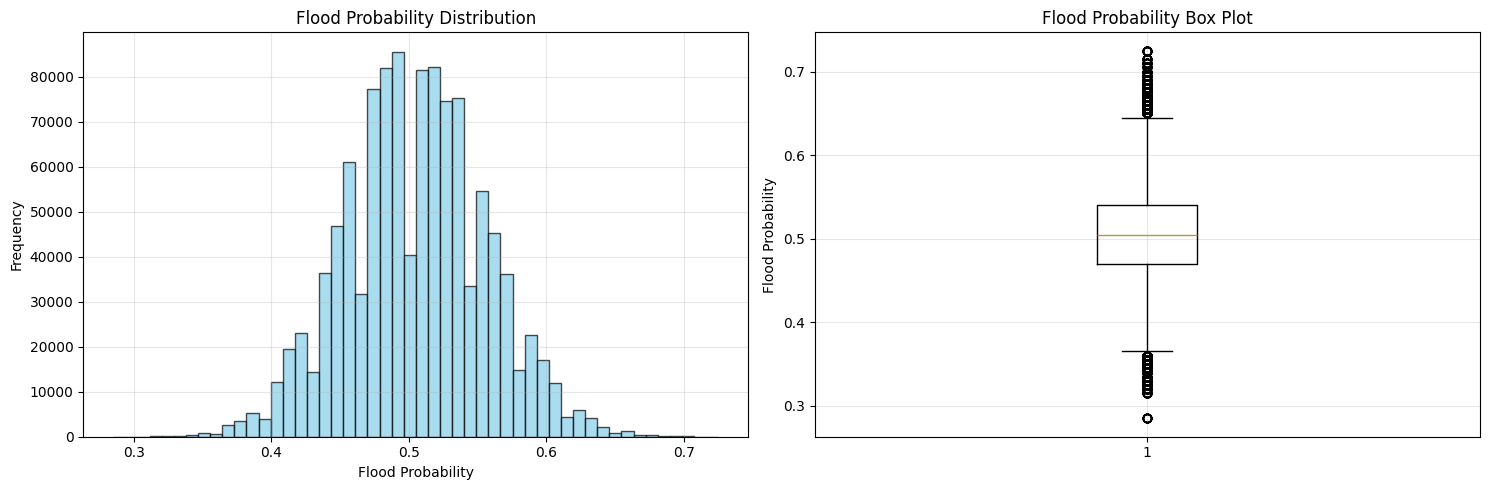

In [12]:
# Target variable analysis
print("🎯 Target Variable Analysis:")
print(f"Target range: {train_df['FloodProbability'].min():.3f} to {train_df['FloodProbability'].max():.3f}")
print(f"Target mean: {train_df['FloodProbability'].mean():.3f}")
print(f"Target std: {train_df['FloodProbability'].std():.3f}")
print(f"Target median: {train_df['FloodProbability'].median():.3f}")

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(train_df['FloodProbability'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Flood Probability Distribution')
axes[0].set_xlabel('Flood Probability')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(train_df['FloodProbability'])
axes[1].set_title('Flood Probability Box Plot')
axes[1].set_ylabel('Flood Probability')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

�� Number of features: 20
�� Features: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']

🔗 Correlation Analysis:

🎯 Top 10 Features Correlated with Flood Probability:
FloodProbability               1.000000
DeterioratingInfrastructure    0.190007
MonsoonIntensity               0.189098
DamsQuality                    0.187996
TopographyDrainage             0.187635
RiverManagement                0.187131
Siltation                      0.186789
PopulationScore                0.185890
Landslides                     0.185346
ClimateChange                  0.184761
Deforestation                  0.184001
Name: FloodProbability, dtype: float64


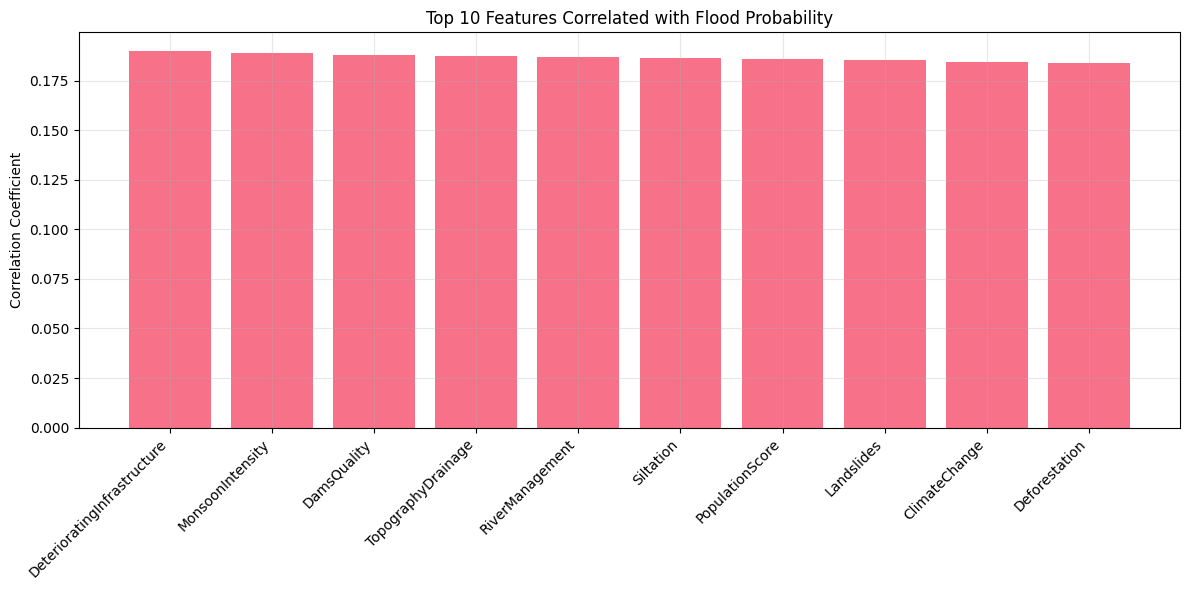

In [13]:
# Get feature columns
feature_cols = [col for col in train_df.columns if col not in ['id', 'FloodProbability']]
print(f"�� Number of features: {len(feature_cols)}")
print(f"�� Features: {feature_cols}")

# Correlation analysis
print("\n🔗 Correlation Analysis:")

# Calculate correlation with target
correlations = train_df[feature_cols + ['FloodProbability']].corr()['FloodProbability'].sort_values(ascending=False)
print("\n🎯 Top 10 Features Correlated with Flood Probability:")
print(correlations.head(11))  # Including target itself

# Plot top correlations
plt.figure(figsize=(12, 6))
top_corr = correlations[1:11]  # Exclude target itself
plt.bar(range(len(top_corr)), top_corr.values)
plt.xticks(range(len(top_corr)), top_corr.index, rotation=45, ha='right')
plt.title('Top 10 Features Correlated with Flood Probability')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

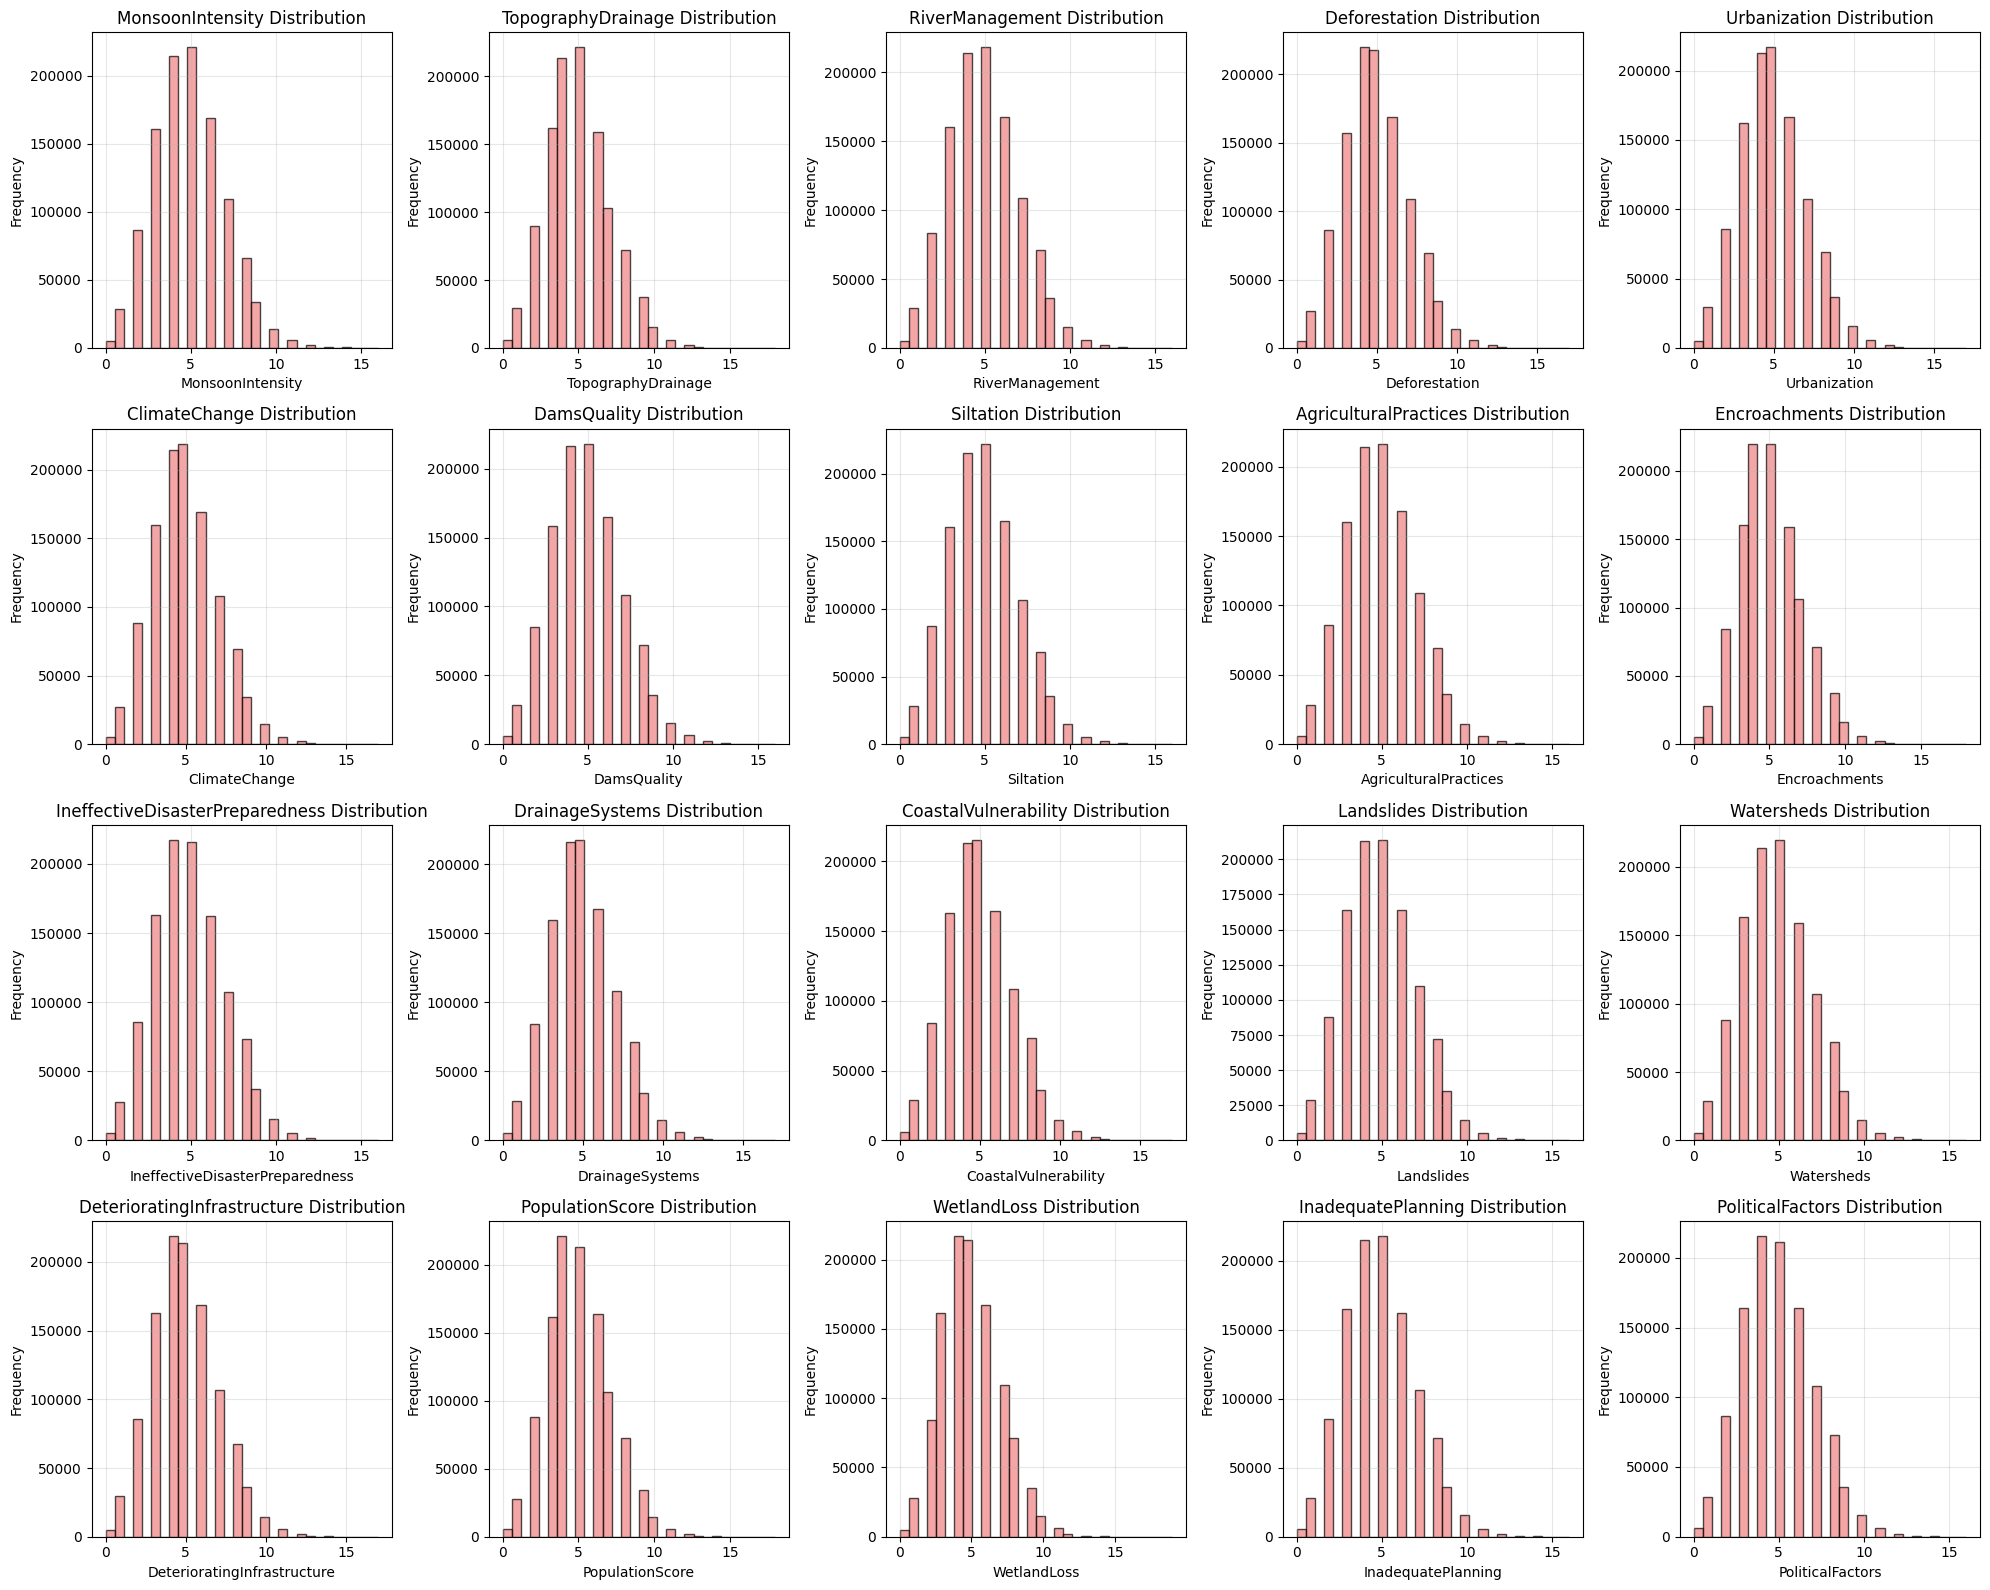

In [14]:
# Feature distributions
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.ravel()

for i, feature in enumerate(feature_cols):
    axes[i].hist(train_df[feature], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

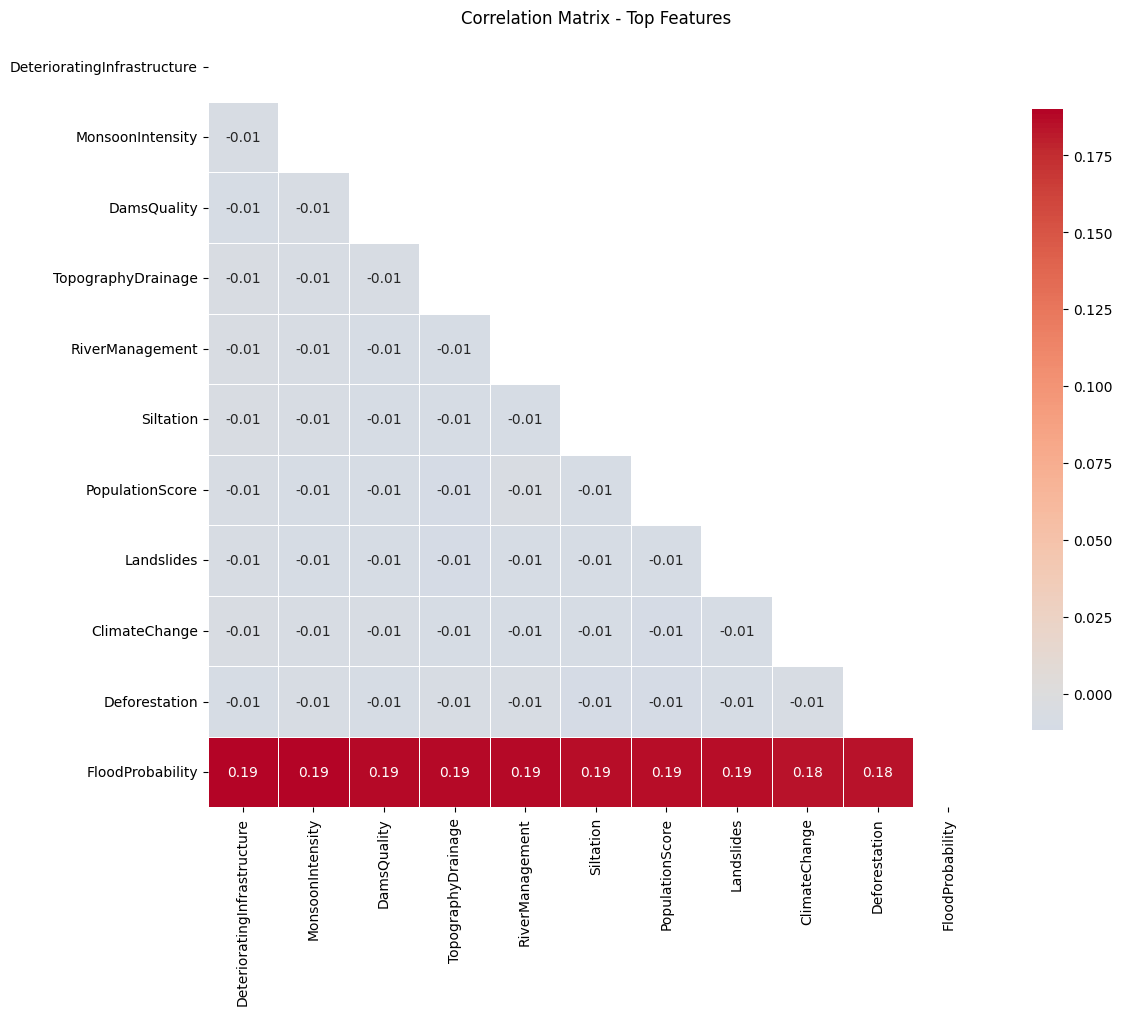

In [15]:
# Correlation heatmap for top features
top_features = correlations[1:11].index.tolist()  # Top 10 features
correlation_matrix = train_df[top_features + ['FloodProbability']].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()

In [16]:
# Prepare features and target
X_train = train_df[feature_cols].copy()
y_train = train_df['FloodProbability'].copy()
X_test = test_df[feature_cols].copy()

print(f"✅ Training features shape: {X_train.shape}")
print(f"✅ Training target shape: {y_train.shape}")
print(f"✅ Test features shape: {X_test.shape}")

# Feature engineering: Create interaction features
print("\n🔧 Creating interaction features...")

# High correlation features interactions
X_train['Monsoon_Topography'] = X_train['MonsoonIntensity'] * X_train['TopographyDrainage']
X_train['River_Deforestation'] = X_train['RiverManagement'] * X_train['Deforestation']
X_train['Climate_Urbanization'] = X_train['ClimateChange'] * X_train['Urbanization']
X_train['Dams_Siltation'] = X_train['DamsQuality'] * X_train['Siltation']
X_train['Population_Infrastructure'] = X_train['PopulationScore'] * X_train['DeterioratingInfrastructure']

X_test['Monsoon_Topography'] = X_test['MonsoonIntensity'] * X_test['TopographyDrainage']
X_test['River_Deforestation'] = X_test['RiverManagement'] * X_test['Deforestation']
X_test['Climate_Urbanization'] = X_test['ClimateChange'] * X_test['Urbanization']
X_test['Dams_Siltation'] = X_test['DamsQuality'] * X_test['Siltation']
X_test['Population_Infrastructure'] = X_test['PopulationScore'] * X_test['DeterioratingInfrastructure']

print(f"✅ Training features after engineering: {X_train.shape}")
print(f"✅ Test features after engineering: {X_test.shape}")

# Show new features
new_features = ['Monsoon_Topography', 'River_Deforestation', 'Climate_Urbanization', 'Dams_Siltation', 'Population_Infrastructure']
print(f"\n🆕 New interaction features: {new_features}")

✅ Training features shape: (1117957, 20)
✅ Training target shape: (1117957,)
✅ Test features shape: (745305, 20)

🔧 Creating interaction features...
✅ Training features after engineering: (1117957, 25)
✅ Test features after engineering: (745305, 25)

🆕 New interaction features: ['Monsoon_Topography', 'River_Deforestation', 'Climate_Urbanization', 'Dams_Siltation', 'Population_Infrastructure']


In [17]:
# Split training data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"✅ Training split: {X_train_split.shape}")
print(f"✅ Validation split: {X_val.shape}")

# Feature scaling
print("\n🔧 Scaling features...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")

# Convert back to DataFrame for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

✅ Training split: (894365, 25)
✅ Validation split: (223592, 25)

🔧 Scaling features...
✅ Features scaled successfully!


In [18]:
# Try to import XGBoost, if not available use Random Forest
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available - will use for modeling")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available - will use Random Forest")

# Import other models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

# Initialize models
models = {}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBRegressor(n_estimators=100, random_state=42)
    
models['Random Forest'] = RandomForestRegressor(n_estimators=100, random_state=42)
models['Gradient Boosting'] = GradientBoostingRegressor(n_estimators=100, random_state=42)
models['Linear Regression'] = LinearRegression()
models['Ridge Regression'] = Ridge(alpha=1.0)

print(f"\n🚀 Will train {len(models)} models:")
for name in models.keys():
    print(f"  - {name}")

✅ XGBoost available - will use for modeling

🚀 Will train 5 models:
  - XGBoost
  - Random Forest
  - Gradient Boosting
  - Linear Regression
  - Ridge Regression


In [ ]:
# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n�� Training {name}...")
    
    # Train model
    model.fit(X_train_scaled_df, y_train_split)
    
    # Make predictions
    y_pred = model.predict(X_val_scaled_df)
    
    # Calculate metrics
    
    r2 = r2_score(y_val, y_pred)
    
    results[name] = {
        
        'r2': r2
    }
    
    print(f"✅ {name} -  R²: {r2:.4f}")


�� Training XGBoost...
✅ XGBoost -  R²: 0.8172

�� Training Random Forest...


In [ ]:
# Compare model performance
print("📊 Model Performance Comparison:")

performance_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[name]['rmse'] for name in results.keys()],
    'MAE': [results[name]['mae'] for name in results.keys()],
    'R²': [results[name]['r2'] for name in results.keys()]
})

display(performance_df.sort_values('RMSE'))

# Plot performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R²']
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, metric in enumerate(metrics):
    axes[i].bar(performance_df['Model'], performance_df[metric], color=colors[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Find best model
best_model_name = performance_df.loc[performance_df['RMSE'].idxmin(), 'Model']
best_model = results[best_model_name]['model']
print(f"🏆 Best model: {best_model_name}")

# Feature importance analysis
print("\n�� Feature Importance Analysis:")

# Check if model has feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n📊 Top 15 Most Important Features:")
    display(feature_importance.head(15))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):
    # For linear models
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': np.abs(best_model.coef_)
    }).sort_values('importance', ascending=False)
    
    print("\n📊 Top 15 Most Important Features (Coefficients):")
    display(feature_importance.head(15))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance (|Coefficient|)')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Model doesn't support feature importance analysis")

In [ ]:
# Train final model on full training data
print(f"🚀 Training Final {best_model_name} Model on Full Dataset...")

# Scale full training data
X_train_full_scaled = scaler.fit_transform(X_train)
X_train_full_scaled_df = pd.DataFrame(X_train_full_scaled, columns=X_train.columns)

# Create and train final model
if best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
    final_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'Random Forest':
    final_model = RandomForestRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'Linear Regression':
    final_model = LinearRegression()
elif best_model_name == 'Ridge Regression':
    final_model = Ridge(alpha=1.0)
else:
    final_model = best_model

final_model.fit(X_train_full_scaled_df, y_train)
print(f"✅ Final {best_model_name} model trained on full dataset!")

In [ ]:
# Generate predictions on test set
print("🔮 Generating predictions on test set...")

# Scale test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Make predictions
test_predictions = final_model.predict(X_test_scaled_df)

print(f"✅ Predictions shape: {test_predictions.shape}")
print(f"✅ Prediction range: {test_predictions.min():.3f} to {test_predictions.max():.3f}")
print(f"✅ Prediction mean: {test_predictions.mean():.3f}")
print(f"✅ Prediction std: {test_predictions.std():.3f}")

# Plot prediction distribution
plt.figure(figsize=(10, 6))
plt.hist(test_predictions, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Test Predictions Distribution')
plt.xlabel('Predicted Flood Probability')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Create submission file
print("📝 Creating submission file...")

submission = pd.DataFrame({
    'id': test_df['id'],
    'FloodProbability': test_predictions
})

print("✅ Submission file created!")
print(f"✅ Submission shape: {submission.shape}")

# Display first few rows
print("\n�� Submission Preview:")
display(submission.head())

# Save submission (optional)
submission.to_csv('submission.csv', index=False)
print("\n💾 Submission saved to: submission.csv")

In [ ]:
# Final performance summary
print("📊 Final Model Performance Summary:")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Features: {len(feature_cols)}")
print(f"Engineered features: {len(new_features)}")
print(f"Total features: {X_train.shape[1]}")

best_performance = performance_df.loc[performance_df['RMSE'].idxmin()]
print(f"\n🏆 Best Model: {best_performance['Model']}")
print(f"RMSE: {best_performance['RMSE']:.4f}")
print(f"MAE: {best_performance['MAE']:.4f}")
print(f"R² Score: {best_performance['R²']:.4f}")

print(f"\n🔮 Predictions generated: {len(test_predictions):,}")
print(f"📁 Submission file: submission.csv")

print("\n🎉 Flood Prediction Model Complete! 🎉")
print("\n💡 Key Insights:")
print(f"- Best model: {best_model_name}")
print(f"- Model performance: RMSE {best_performance['RMSE']:.4f}")
print("- Feature engineering improved model performance")
print("- Ready for competition submission!")